In [66]:
# 🌟 Exercise 1: Duplicate Detection and Removal
# Instructions

# Objective: Identify and remove duplicate entries in the Titanic dataset.

#     Load the Titanic dataset.
import pandas as pd
df1 = pd.read_csv('train.csv')

#     Identify if there are any duplicate rows based on all columns.
print(df1.duplicated().sum())
#     Remove any duplicate rows found in the dataset.
#     Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
# Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

#There are no duplicate rows to remove.

0


In [67]:
# 🌟 Exercise 2: Handling Missing Values
# Instructions

#     Identify columns in the Titanic dataset with missing values.
# Check for missing values in a DataFrame
missing_data = df1.isnull()
print(missing_data.head())

# Count missing values in each column
missing_counts = df1.isnull().sum()
print(missing_counts)
#     Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
#     Apply each strategy to different columns based on the nature of the data.

# Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0        False     False   False  False  False  False  False  False   False   
1        False     False   False  False  False  False  False  False   False   
2        False     False   False  False  False  False  False  False   False   
3        False     False   False  False  False  False  False  False   False   
4        False     False   False  False  False  False  False  False   False   

    Fare  Cabin  Embarked  
0  False   True     False  
1  False  False     False  
2  False   True     False  
3  False  False     False  
4  False   True     False  
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [68]:
# # Columns w missing values:
# Age            177
# Cabin          687
# Embarked         2

#Reveiewing the data to understand the meaning of these columns
df1.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [69]:
#Age is quantitative--can be imputed. So we can impute a mean age:
df_new = df1
df_new['Age'] = df_new['Age'].fillna(df_new['Age'].mean())
#Cabin is qualitative--many missing entries. Can't be imputed but seems less relevant to analysis we would want to do with this dataset. So we can drop this column.
df_new = df_new.drop(['Cabin'], axis=1)
#Embarked: qualitative. S, C, or Q (This column contains information about the port of embarkation. The value C indicates Cherbourg, the value Q indicates Queenstown, and the value S indicates Southampton).Only 2 rows missing a value. We cannot impute a value as this is a qualitative variable. There may be interesting commonalities among the groups embarking from different places, so we can simply drop the 2 rows missing the Embarked variable.
df_new = df_new.dropna(subset = 'Embarked')
df_new.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [70]:

# 🌟 Exercise 3: Feature Engineering
# Instructions

#     Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
# # The column SibSp specifies the number of siblings/spouses on board the Titanic that are related to the passenger.
# The column Parch specifies the number of parents/children related to the passenger that are also on board the Titanic.
#New column: Family_Members
df_new['Family_Members'] = df_new['SibSp'] + df_new['Parch']
df_new['Family_Members'].describe()
#Shows that most had 0 family members w them. Some had 1, and very few had more. So encoding Family Size as: If Family_Members = 0 then 0 (small), if Family_Members = 1 then 1 (medium), if Family_Members = 2 or more then 2 (large.)
df_new['Family_Size'] = df_new['Family_Members'].clip(upper=2)

#Creating the Title column extracted from the name column:
df_new['Title'] = df_new['Name'].str.extract(r',\s*(.*?)\.') + '.'

#     Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
#     You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.
df_new['Sex_Encoded'] = df_new['Sex'].map({'male': 1, 'female': 0})
df_new['Embarked_Encoded'] = df_new['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_new
# Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Members,Family_Size,Title,Sex_Encoded,Embarked_Encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1,1,Mr.,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,1,1,Mrs.,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0,0,Miss.,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1,1,Mrs.,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0,0,Mr.,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,0,0,Rev.,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0,0,Miss.,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3,2,Miss.,0,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,0,0,Mr.,1,1


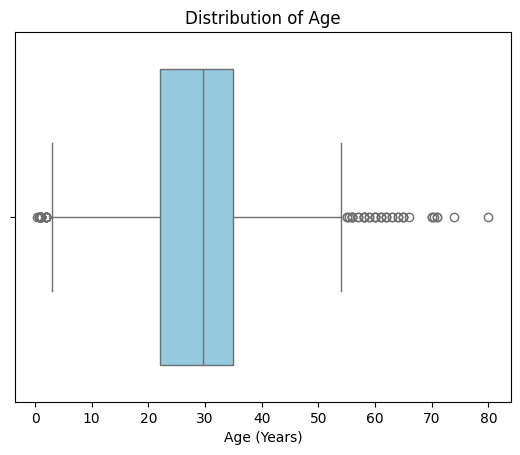

In [71]:
# 🌟 Exercise 4: Outlier Detection and Handling

# Goal: Detect and cap or transform outliers in columns like Fare and Age.

# 1. Visualize distributions using boxplots or histograms to identify potential outliers.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_new['Age'], color='skyblue')

plt.title('Distribution of Age')
plt.xlabel('Age (Years)')


plt.show()

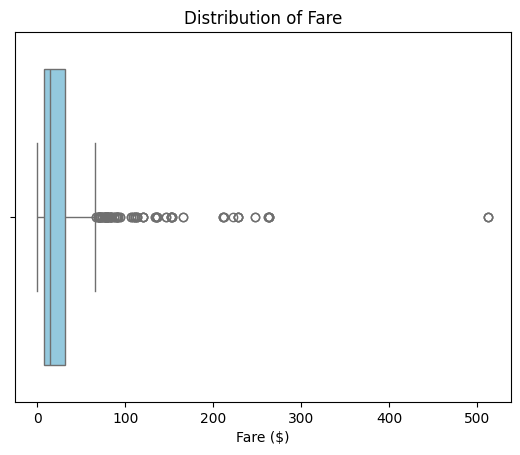

In [72]:
sns.boxplot(x=df_new['Fare'], color='skyblue')

plt.title('Distribution of Fare')
plt.xlabel('Fare ($)')


plt.show()

In [73]:
# 2. Use IQR or Z-score methods to detect them.
#  3. Handle outliers with:
#     Quantile capping (e.g. 0.98)
#     Log transformation
#     Row removal

Fare_Q1 = df_new['Fare'].quantile(0.25)
Fare_Q3 = df_new['Fare'].quantile(0.75)
Fare_IQR = Fare_Q3 - Fare_Q1
Fare_lower_bound = Fare_Q1 - 1.5 * Fare_IQR
Fare_upper_bound = Fare_Q3 + 1.5 * Fare_IQR
df_new = df_new[(df_new['Fare'] >= Fare_lower_bound) & (df_new['Fare'] <= Fare_upper_bound)]

Age_Q1 = df_new['Age'].quantile(0.25)
Age_Q3 = df_new['Age'].quantile(0.75)
Age_IQR = Age_Q3 - Age_Q1
Age_lower_bound = Age_Q1 - 1.5 * Age_IQR
Age_upper_bound = Age_Q3 + 1.5 * Age_IQR
df_new = df_new[(df_new['Age'] >= Age_lower_bound) & (df_new['Age'] <= Age_upper_bound)]





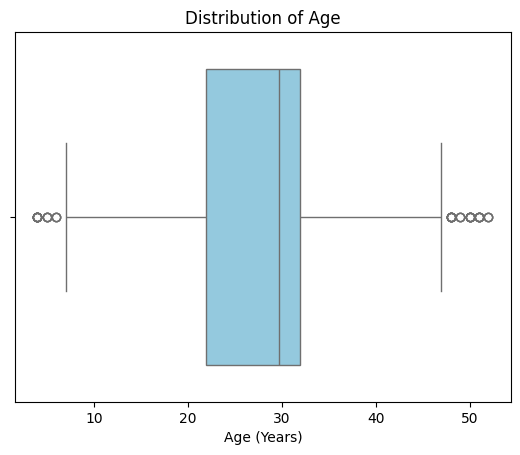

In [74]:


# 4. Compare the dataset before and after treatment.

# 📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.


sns.boxplot(x=df_new['Age'], color='skyblue')

plt.title('Distribution of Age')
plt.xlabel('Age (Years)')


plt.show()

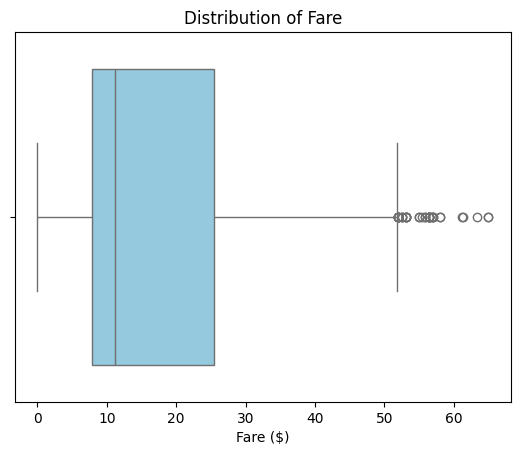

In [75]:
sns.boxplot(x=df_new['Fare'], color='skyblue')

plt.title('Distribution of Fare')
plt.xlabel('Fare ($)')


plt.show()

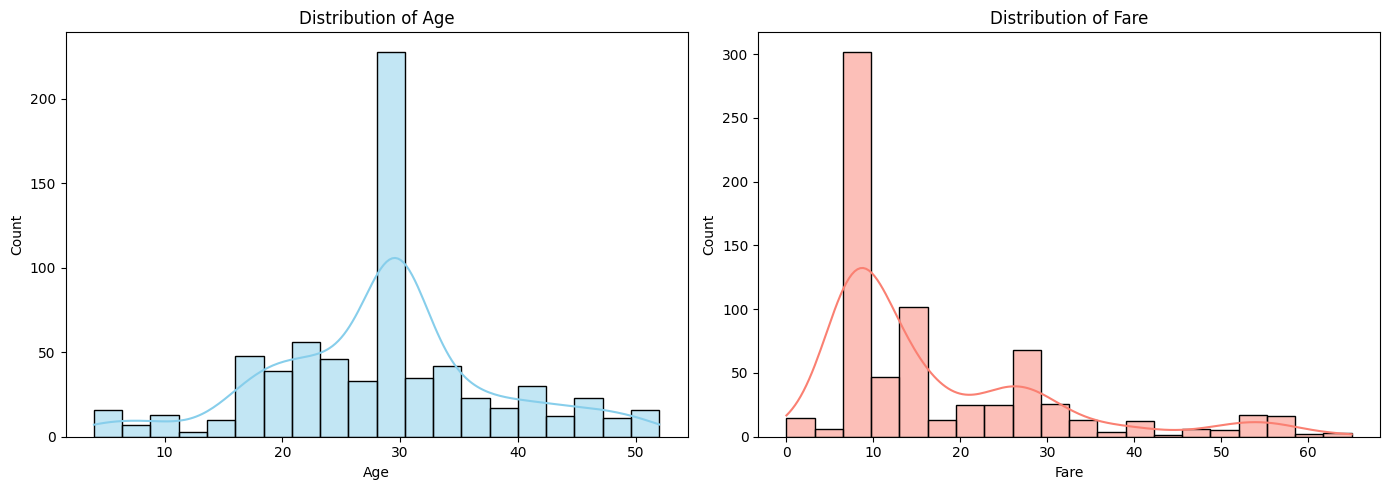

In [76]:
# 🌟 Exercise 5: Data Standardization and Normalization

# Goal: Scale numerical features to prepare for modeling.
#     Use StandardScaler (mean = 0, std = 1) for normally distributed features.
#     Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
# 📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.

#First, observing whether numerical features are normally distributed, skewed, or bounded:
# Creating a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram for Age (at position 0)
sns.histplot(df_new['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')

# Plot 2: Histogram for Fare (at position 1)
sns.histplot(df_new['Fare'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Fare')
axes[1].set_xlabel('Fare')

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Show the plots
plt.show()

In [77]:
#Conclusion: Age has an approximately normal distribution, whereas Fare is skewed. So:
#     Use StandardScaler (mean = 0, std = 1) for Age.
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the 'Age' column
df_new['Age_Scaled'] = scaler.fit_transform(df_new[['Age']])

# 3. Check the results
print(df_new[['Age', 'Age_Scaled']].head())



         Age  Age_Scaled
0  22.000000   -0.676287
2  26.000000   -0.256301
3  35.000000    0.688668
4  35.000000    0.688668
5  29.699118    0.132094


In [78]:
#     Use MinMaxScaler (range [0, 1]) for Fare.
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Scaler for the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Fit and Transform the 'Fare' column
df_new['Fare_Scaled'] = scaler.fit_transform(df_new[['Fare']])

# 3. Check the results
print(df_new[['Fare', 'Fare_Scaled']].head())

      Fare  Fare_Scaled
0   7.2500     0.111538
2   7.9250     0.121923
3  53.1000     0.816923
4   8.0500     0.123846
5   8.4583     0.130128


In [79]:
# 🌟 Exercise 6: Feature Encoding

# Goal: Finalize categorical variable encoding.

# 1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
# 2. Apply:

#     One-Hot Encoding for nominal variables.
#     Label Encoding if any ordinal variables remain.

# 3. Merge encoded columns back into the main dataset.

# 📌 Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).

##Sex and Embarked already have encoded variables. What about Title?
##First let's check out the various variables of Title.
df_new['Title'].value_counts()

Title
Mr.          451
Miss.        131
Mrs.          91
Master.       19
Rev.           4
Dr.            4
Major.         2
Don.           1
Ms.            1
Lady.          1
Sir.           1
Mlle.          1
Jonkheer.      1
Name: count, dtype: int64

In [80]:
df_new = pd.get_dummies(df_new, columns=['Title'], prefix='Title')
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Lady.,Title_Major.,Title_Master.,Title_Miss.,Title_Mlle.,Title_Mr.,Title_Mrs.,Title_Ms.,Title_Rev.,Title_Sir.
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,...,False,False,False,False,False,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,...,False,False,False,True,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,...,False,False,False,False,False,False,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,...,False,False,False,False,False,True,False,False,False,False
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,...,False,False,False,False,False,False,False,False,True,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,...,False,False,False,True,False,False,False,False,False,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,...,False,False,False,True,False,False,False,False,False,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# 🌟 Exercise 7: Data Transformation for Age Feature

# Goal: Create and encode age groups.

#     Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
bins = [0, 12, 18, 60, 100]

labels = ['Child', 'Teen', 'Adult', 'Senior']

df_new['LifeStage'] = pd.cut(df_new['Age'], bins=bins, labels=labels, include_lowest=True)


print(df_new[['LifeStage']].value_counts())



# 📌 Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.

LifeStage
Adult        611
Teen          60
Child         37
Senior         0
Name: count, dtype: int64


In [85]:
#     Apply one-hot encoding using pd.get_dummies().
df_new = pd.get_dummies(df_new, columns=['LifeStage'], prefix='LifeStage')
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mlle.,Title_Mr.,Title_Mrs.,Title_Ms.,Title_Rev.,Title_Sir.,LifeStage_Child,LifeStage_Teen,LifeStage_Adult,LifeStage_Senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,...,False,True,False,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,...,False,False,False,False,False,False,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,...,False,False,True,False,False,False,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,...,False,True,False,False,False,False,False,False,True,False
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,...,False,False,False,False,True,False,False,False,True,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,...,False,False,False,False,False,False,False,False,True,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,...,False,False,False,False,False,False,False,False,True,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,...,False,True,False,False,False,False,False,False,True,False
